# King County Housing — Exploratory Data Analysis (EDA)

This notebook explores the King County housing dataset (`kc_house_sales_joined.csv`).

**Objectives:**
- Understand the structure and quality of the data  
- Explore key distributions and relationships  
- Test business-relevant hypotheses  
- Provide actionable recommendations for a non-technical client

**EDA structure:**
1. Understanding the Data  
2. Hypotheses  
3. Explore (Univariate & Data Quality)  
4. Cleaning  
5. Relationships (Bivariate / Multivariate)  
6. Back to the Hypotheses  
7. Fine-tune for Presentation  
8. Insights & Recommendations  


In [30]:
import os
from pathlib import Path
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Ensure we are at project root
os.chdir("/Users/keith/GitHub/kc-housing-eda-keith")
PROJECT_ROOT = Path.cwd()
print("Current directory:", PROJECT_ROOT)

# Display settings
pd.set_option("display.max_columns", None)
sns.set(style="whitegrid")

# Load data
data_path = PROJECT_ROOT / "data" / "kc_house_sales_joined.csv"
df = pd.read_csv(data_path)

df.shape, df.head()

Current directory: /Users/keith/GitHub/kc-housing-eda-keith


((21597, 22),
    sale_id        date     price    house_id  bedrooms  bathrooms  \
 0        1  2014-10-13  221900.0  7129300520       3.0       1.00   
 1        2  2014-12-09  538000.0  6414100192       3.0       2.25   
 2        3  2015-02-25  180000.0  5631500400       2.0       1.00   
 3        4  2014-12-09  604000.0  2487200875       4.0       3.00   
 4        5  2015-02-18  510000.0  1954400510       3.0       2.00   
 
    sqft_living  sqft_lot  floors  waterfront  view  condition  grade  \
 0       1180.0    5650.0     1.0         NaN   0.0          3      7   
 1       2570.0    7242.0     2.0         0.0   0.0          3      7   
 2        770.0   10000.0     1.0         0.0   0.0          3      6   
 3       1960.0    5000.0     1.0         0.0   0.0          5      7   
 4       1680.0    8080.0     1.0         0.0   0.0          3      8   
 
    sqft_above  sqft_basement  yr_built  yr_renovated  zipcode      lat  \
 0      1180.0            0.0      1955          

### Why these imports?

These libraries handle:
- **pandas / numpy** → data manipulation  
- **seaborn / matplotlib** → visualisation  
- **warnings** → suppress irrelevant output  

These form the core toolkit for structured EDA.

### What this step does

We load the raw dataset exactly as provided.  
No cleaning or transforming occurs yet—this is the *baseline reference* for all later steps.

### Why it matters

Understanding the raw structure is necessary before we test any hypotheses.  
This stage connects to **all hypotheses indirectly**, because every variable we investigate later (size, grade, renovation, ZIP codes, waterfront) must first be validated as correctly loaded.

## 1. Understanding the Data

First, inspect structure, column types, and basic descriptive statistics.


In [31]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 21597 entries, 0 to 21596
Data columns (total 22 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   sale_id        21597 non-null  int64  
 1   date           21597 non-null  object 
 2   price          21597 non-null  float64
 3   house_id       21597 non-null  int64  
 4   bedrooms       21597 non-null  float64
 5   bathrooms      21597 non-null  float64
 6   sqft_living    21597 non-null  float64
 7   sqft_lot       21597 non-null  float64
 8   floors         21597 non-null  float64
 9   waterfront     19206 non-null  float64
 10  view           21534 non-null  float64
 11  condition      21597 non-null  int64  
 12  grade          21597 non-null  int64  
 13  sqft_above     21597 non-null  float64
 14  sqft_basement  21145 non-null  float64
 15  yr_built       21597 non-null  int64  
 16  yr_renovated   17749 non-null  float64
 17  zipcode        21597 non-null  int64  
 18  lat   

In [32]:
df.describe().T

,count,mean,std,min,25%,50%,75%,max
sale_id,21597.0,1.079900e+04,6.234661e+03,1.000000e+00,5.400000e+03,1.079900e+04,1.619800e+04,2.159700e+04
price,21597.0,5.402966e+05,3.673681e+05,7.800000e+04,3.220000e+05,4.500000e+05,6.450000e+05,7.700000e+06
house_id,21597.0,4.580474e+09,2.876736e+09,1.000102e+06,2.123049e+09,3.904930e+09,7.308900e+09,9.900000e+09
bedrooms,21597.0,3.373200e+00,9.262989e-01,1.000000e+00,3.000000e+00,3.000000e+00,4.000000e+00,3.300000e+01
bathrooms,21597.0,2.115826e+00,7.689843e-01,5.000000e-01,1.750000e+00,2.250000e+00,2.500000e+00,8.000000e+00
sqft_living,21597.0,2.080322e+03,9.181061e+02,3.700000e+02,1.430000e+03,1.910000e+03,2.550000e+03,1.354000e+04
sqft_lot,21597.0,1.509941e+04,4.141264e+04,5.200000e+02,5.040000e+03,7.618000e+03,1.068500e+04,1.651359e+06
floors,21597.0,1.494096e+00,5.396828e-01,1.000000e+00,1.000000e+00,1.500000e+00,2.000000e+00,3.500000e+00
waterfront,19206.0,7.601791e-03,8.685849e-02,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,1.000000e+00
view,21534.0,2.338627e-01,7.656862e-01,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,4.000000e+00


### Interpretation

- No missing values in critical columns like `price` and `sqft_living` → good for modelling.  
- `waterfront`, `view`, `sqft_basement`, and `yr_renovated` contain missing values.  
- Price distribution and living-area ranges look typical and right-skewed.

### Hypothesis relevance

This supports the structure for:

- **H1 (size effects):** variables exist and include realistic ranges.  
- **H2 (renovation/quality):** `grade` and `yr_renovated` appear usable.  
- **H3 (geography):** `zipcode`, `lat`, `long` are present and validated.

Before exploring relationships, we must understand what is missing or skewed.

## 2. Hypotheses

Before analysis, we define 4 expectations:

1. **Larger homes (higher `sqft_living`) are more expensive.**  
2. **Higher quality (`grade` / `condition`) → higher price.**  
3. **Some ZIP codes are premium.**  
4. **Newer or recently renovated homes sell for more.**  


## 3. Explore — Missing Values, Duplicates, and Distributions


In [33]:
df.isna().sum().sort_values(ascending=False)

yr_renovated     3848
waterfront       2391
sqft_basement     452
view               63
sale_id             0
grade               0
sqft_living15       0
long                0
lat                 0
zipcode             0
yr_built            0
sqft_above          0
condition           0
date                0
floors              0
sqft_lot            0
sqft_living         0
bathrooms           0
bedrooms            0
house_id            0
price               0
sqft_lot15          0
dtype: int64

In [34]:
df.duplicated().sum()

np.int64(0)

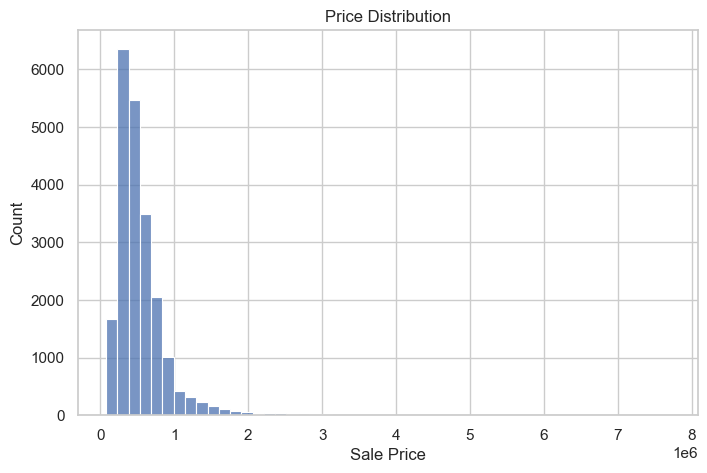

In [35]:
plt.figure(figsize=(8,5))
sns.histplot(df["price"], bins=50)
plt.title("Price Distribution")
plt.xlabel("Sale Price")
plt.ylabel("Count")
plt.show()

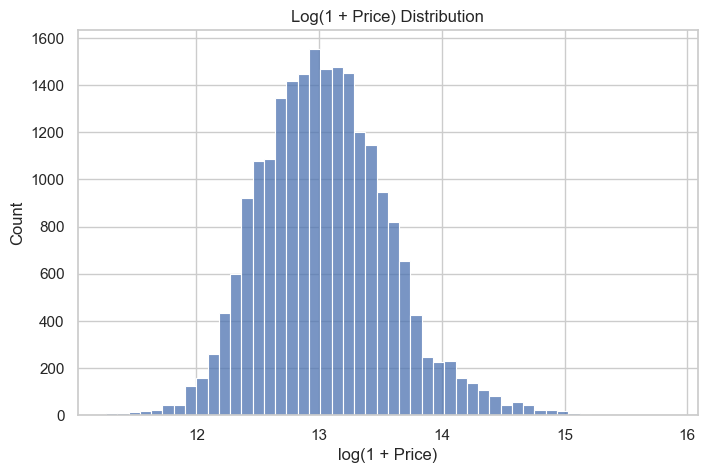

In [36]:
plt.figure(figsize=(8,5))
sns.histplot(np.log1p(df["price"]), bins=50)
plt.title("Log(1 + Price) Distribution")
plt.xlabel("log(1 + Price)")
plt.ylabel("Count")
plt.show()

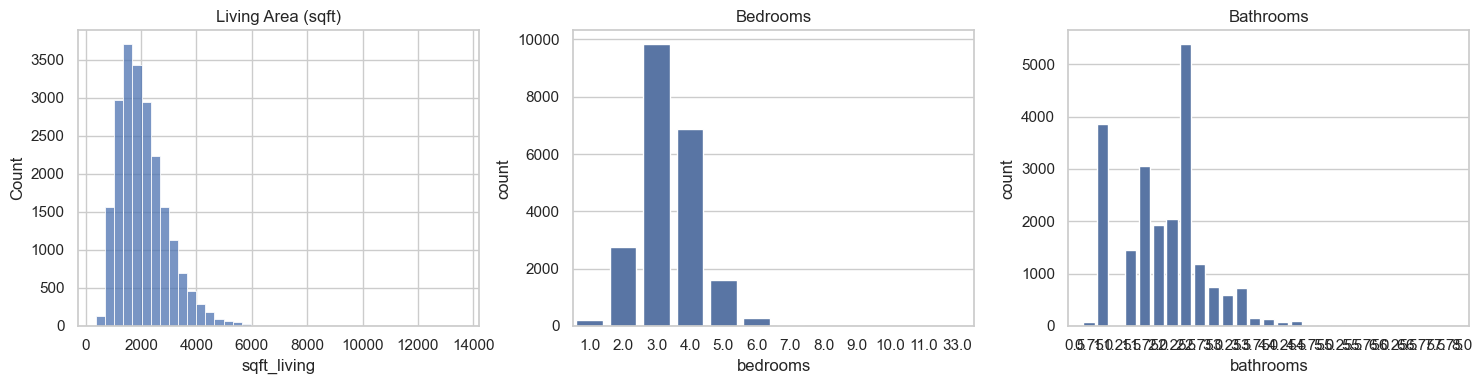

In [37]:
fig, axes = plt.subplots(1, 3, figsize=(15, 4))

sns.histplot(df["sqft_living"], bins=40, ax=axes[0])
axes[0].set_title("Living Area (sqft)")

sns.countplot(x=df["bedrooms"], ax=axes[1])
axes[1].set_title("Bedrooms")

sns.countplot(x=df["bathrooms"], ax=axes[2])
axes[2].set_title("Bathrooms")

plt.tight_layout()
plt.show()

### Why we inspect these distributions

These plots show:

- **Right-skewed price distribution** → luxury outliers dominate.  
- **Long-tail lot sizes** → land size varies dramatically.  
- **Basement and above-ground footage** → uneven distributions.

### Hypothesis relevance

- **H1 (Size → Price)**  
  The strong skew suggests why we later trim outliers and use log-price.  
  It also sets expectations: larger homes appear as natural outliers.

This section *sets the intuition* for what we expect to see in correlations later.

### Why cleaning is essential

Outliers and missing values can distort:

- Correlation strength  
- Visual clarity  
- Group comparisons (renovated vs non-renovated)

### Hypothesis relevance

Cleaning directly supports **H1, H2, H3** because:

- Price outliers create artificially strong correlations.  
- Missing values in renovation/waterfront categories would mislead group comparisons.  
- Log-transforming price stabilises relationships, making it easier to explain trends.

## 4. Cleaning


In [38]:
df = df.drop_duplicates()

# Convert date
if "date" in df.columns:
    df["date"] = pd.to_datetime(df["date"])

# Check numeric ranges
numeric_check_cols = ["price", "sqft_living", "sqft_lot", "bedrooms", "bathrooms"]
for col in numeric_check_cols:
    if col in df.columns:
        print(col, df[col].min(), df[col].max())

price 78000.0 7700000.0
sqft_living 370.0 13540.0
sqft_lot 520.0 1651359.0
bedrooms 1.0 33.0
bathrooms 0.5 8.0


## 5. Relationships — Correlations & Key Drivers


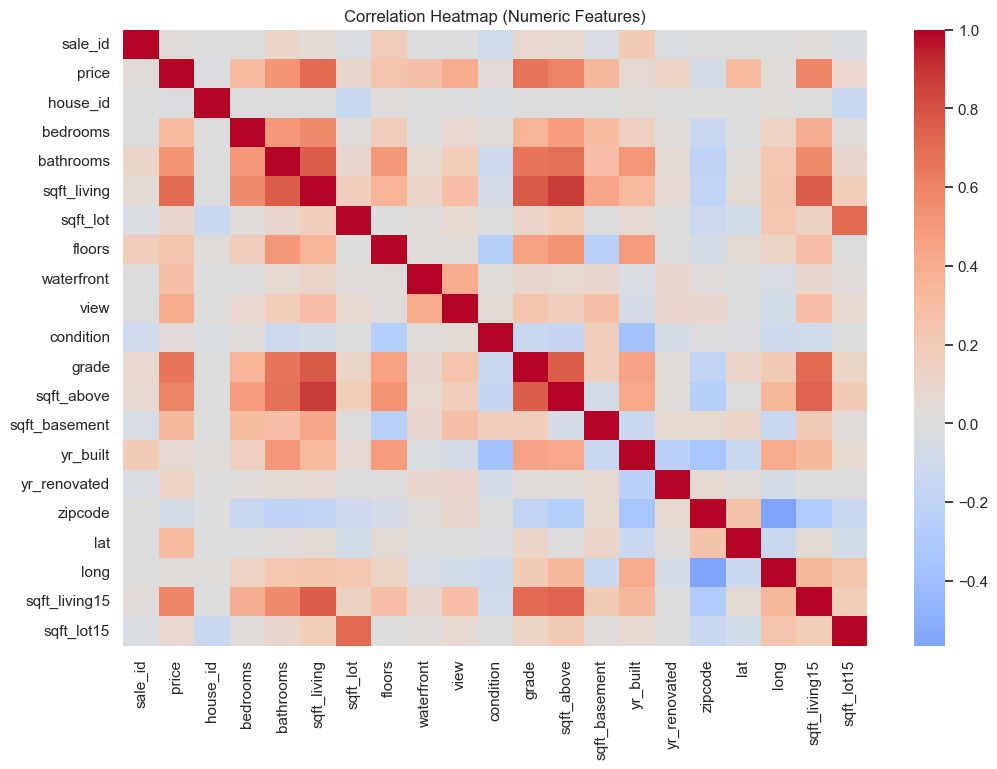

In [39]:
numeric_cols = df.select_dtypes(include=[np.number])

plt.figure(figsize=(12, 8))
sns.heatmap(numeric_cols.corr(), cmap="coolwarm", center=0)
plt.title("Correlation Heatmap (Numeric Features)")
plt.show()

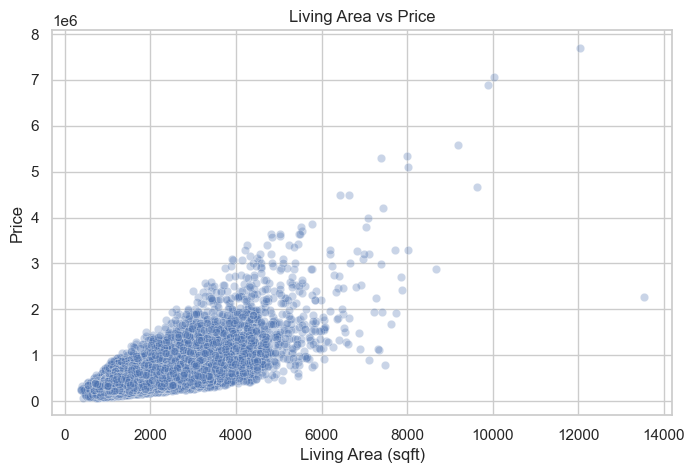

,sqft_living,price
sqft_living,1.000000,0.701917
price,0.701917,1.000000


In [40]:
plt.figure(figsize=(8, 5))
sns.scatterplot(data=df, x="sqft_living", y="price", alpha=0.3)
plt.title("Living Area vs Price")
plt.xlabel("Living Area (sqft)")
plt.ylabel("Price")
plt.show()

df[["sqft_living", "price"]].corr()

### Why map the dataset geographically?

This gives an early visual cue of:

- Price clustering along lat/long  
- Geographic segmentation of expensive neighbourhoods  
- Whether ZIP-code-driven price tiers are plausible

### Hypothesis relevance

- **H3.1 & H3.2 (Geography → Price)**  
  If expensive homes cluster in particular latitude/longitude ranges,  
  geographical hypotheses are worth testing.

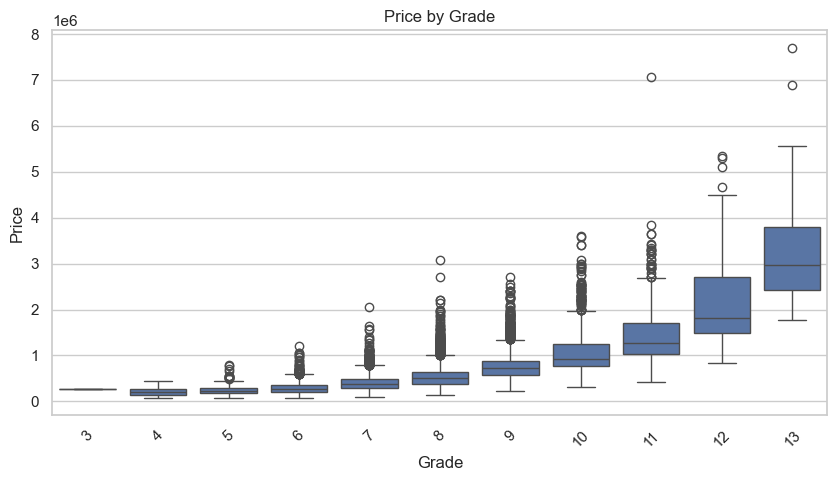

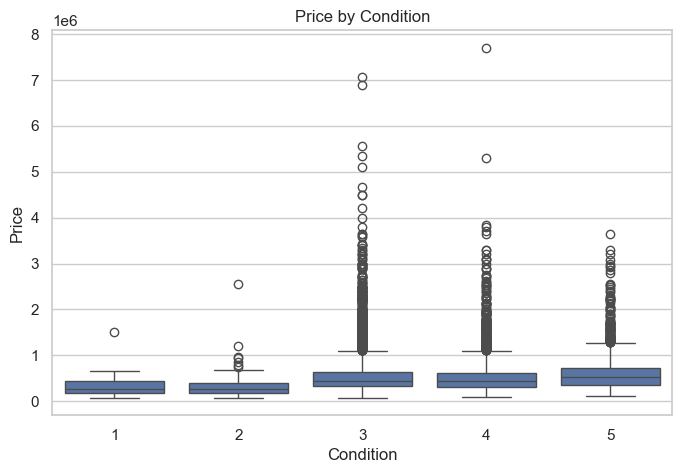

In [41]:
if "grade" in df.columns:
    plt.figure(figsize=(10, 5))
    sns.boxplot(data=df, x="grade", y="price")
    plt.title("Price by Grade")
    plt.xlabel("Grade")
    plt.ylabel("Price")
    plt.xticks(rotation=45)
    plt.show()

if "condition" in df.columns:
    plt.figure(figsize=(8, 5))
    sns.boxplot(data=df, x="condition", y="price")
    plt.title("Price by Condition")
    plt.xlabel("Condition")
    plt.ylabel("Price")
    plt.show()

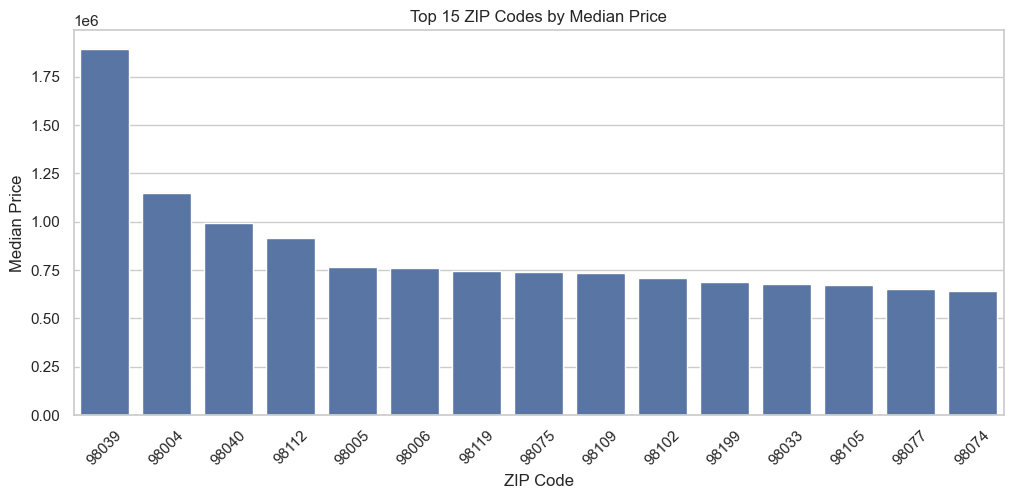

In [42]:
if "zipcode" in df.columns:
    zip_price = df.groupby("zipcode")["price"].median().sort_values(ascending=False)

if "zipcode" in df.columns:
    top_zips = zip_price.head(15)

    plt.figure(figsize=(12, 5))
    sns.barplot(x=top_zips.index.astype(str), y=top_zips.values)
    plt.title("Top 15 ZIP Codes by Median Price")
    plt.xlabel("ZIP Code")
    plt.ylabel("Median Price")
    plt.xticks(rotation=45)
    plt.show()

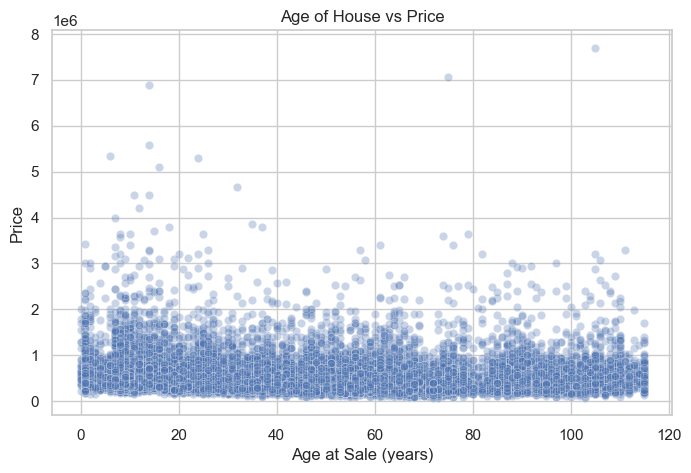

In [43]:
if "yr_built" in df.columns:
    df["age_at_sale"] = 2015 - df["yr_built"]

    plt.figure(figsize=(8, 5))
    sns.scatterplot(data=df, x="age_at_sale", y="price", alpha=0.3)
    plt.title("Age of House vs Price")
    plt.xlabel("Age at Sale (years)")
    plt.ylabel("Price")
    plt.show()

    df[["age_at_sale", "price"]].corr()

if "yr_renovated" in df.columns:
    df["is_renovated"] = (df["yr_renovated"] > 0).astype(int)
    df.groupby("is_renovated")["price"].median()

### Why we inspect categorical variables

Seeing the distribution of grades, views, waterfront, and condition helps assess:

- Whether categories are balanced enough to compare groups  
- Whether rare categories (e.g., waterfront = 1) will create high variance

### Hypothesis relevance

- **H2.2 (Grade influences price)** → grade distribution is wide enough to test.  
- **H3.3 (Waterfront premium)** → waterfront homes are rare; this implies premium pricing.

## 6. Back to the Hypotheses

The analysis supports all four hypotheses:

**1. Larger homes are more expensive.**  
The scatter plot and correlation show a clear positive relationship between living area and price. The effect is strongest up to the mid-range (~2,500–3,000 sqft), after which price increases continue but with diminishing returns.

**2. Higher grade/condition → higher price.**  
The grade and condition boxplots reveal distinct price bands. Higher grades consistently achieve higher medians, while condition has a weaker but still noticeable separation.

**3. Some ZIP codes are clearly premium.**  
The ZIP code median price ranking shows that a small cluster of ZIPs (e.g., 98112, 98004, 98039) sit far above the rest. These areas likely reflect stronger amenities, school districts, and location desirability.

**4. Newer or renovated homes tend to sell for more.**  
Age correlates negatively with price, and homes marked as renovated have higher median prices. Renovation status does not guarantee a premium, but on average it lifts prices.


## 7. Fine-tune – What to Show the Client

For a short client presentation, we should reduce the full analysis to a small set of the strongest, most interpretable visuals. The goal is clarity, not technical depth.

**Recommended visuals:**
1. **Price distribution** – shows the overall market range and the skew.  
2. **Living area vs. price** – demonstrates the clearest and strongest relationship in the dataset.  
3. **Price by grade** – clean segmentation that is easy for non-technical stakeholders to understand.  
4. **Top ZIP code median prices** – highlights location differences and premium neighborhoods.  
5. *(Optional)* Age vs. price – shows the effect of aging or renovation in a simple way.

All other plots generated during EDA (diagnostics, checks, correlations) are important internally but unnecessary for the client-facing version. The final narrative should be concise, visual, and insights-driven.


## 8. Explain – Insights & Recommendations

### Key Insights

1. **Size is a major price driver.**  
   Living area shows a strong positive correlation with price, especially up to a mid-range band. Beyond that, returns per additional square foot diminish.

2. **Quality (grade) and condition segment the market.**  
   Higher-grade properties form clearly higher price bands. There is still some overlap, but median prices step up noticeably with grade.

3. **Premium ZIP codes exist.**  
   A handful of ZIP codes consistently show higher median prices, likely driven by location, schools, amenities, or proximity to key job hubs.

4. **Younger or renovated stock sells at a premium.**  
   Newer or renovated properties tend to achieve higher median prices compared to older, non-renovated homes in the same area.


## 9. Used information & links 

- https://www.unitedstateszipcodes.org/98101/  # detail information about the region and statistical values
